<a href="https://colab.research.google.com/github/Suharyanto-env/Sampah-Dumai/blob/main/Peta2d_Index_Sampah_Kec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
# 1. Install & import

!pip install geopandas folium openpyxl

import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt

In [103]:
# 2. Link google sheet format CSV

url = "https://docs.google.com/spreadsheets/d/1DoMXP81Kt1yK2C1Y-c_jhPQlYghqfBKqD8o9ZYOErVA/export?format=csv"
df = pd.read_csv(url)

#  3. Cek Data

Pastikan ada:
Kecamatan, Penduduk, Rasio, Timbulan, Terangkut,
BS, %RT, RT, Terolah, Reduksi, Liar, Hidden, %Leaked

In [104]:
print("Kolom data:")
print(df.columns)

print("\nPreview:")
print(df.head())

Kolom data:
Index(['No', 'nama_kecamatan', 'Penduduk', 'Rasio', 'Timbulan', '% pelayanan',
       'Terangkut', 'BS', '%RT', 'RT', 'Terolah', 'Reduksi', 'Liar', 'Hidden',
       'Leaked', '%Leaked'],
      dtype='object')

Preview:
   No   nama_kecamatan  Penduduk  Rasio  Timbulan % pelayanan  Terangkut  \
0   1      Dumai Timur     67000    0.8     53600         25%    13400.0   
1   2      Dumai Barat     44200    0.7     30940         70%    21658.0   
2   3      Bukit Kapur     49000    0.7     34300         50%    17150.0   
3   4    Medang Kampai     14500    0.7     10150         25%     2537.5   
4   5  Sungai Sembilan     38000    0.7     26600          0%        0.0   

     BS   %RT    RT  Terolah  Reduksi  Liar   Hidden   Leaked  %Leaked  
0   100  0.01   536      636      500  1000  38064.0  39064.0    72.88  
1   750  0.15  4641     5391     2000  1600    291.0   1891.0     6.11  
2  1000  0.25  8575     9575     4000  2500   1075.0   3575.0    10.42  
3  1500  0.10  1015 

In [105]:
# Rapikan format Data

df.columns = df.columns.str.strip()

# ubah ke numeric (anti error tipe data)
cols = ["Timbulan","Terangkut","Terolah","Reduksi","%Leaked"]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [106]:
# Hitung persen kebocoran

df["persen_kebocoran"] = (
    (df["Timbulan"] - (df["Terangkut"] + df["Terolah"] + df["Reduksi"]))
    / df["Timbulan"]
) * 100

In [107]:
# Output 1 : Tabel

print(df)

   No   nama_kecamatan  Penduduk  Rasio  Timbulan % pelayanan  Terangkut  \
0   1      Dumai Timur     67000    0.8     53600         25%    13400.0   
1   2      Dumai Barat     44200    0.7     30940         70%    21658.0   
2   3      Bukit Kapur     49000    0.7     34300         50%    17150.0   
3   4    Medang Kampai     14500    0.7     10150         25%     2537.5   
4   5  Sungai Sembilan     38000    0.7     26600          0%        0.0   

     BS   %RT    RT  Terolah  Reduksi  Liar   Hidden   Leaked  %Leaked  \
0   100  0.01   536      636      500  1000  38064.0  39064.0    72.88   
1   750  0.15  4641     5391     2000  1600    291.0   1891.0     6.11   
2  1000  0.25  8575     9575     4000  2500   1075.0   3575.0    10.42   
3  1500  0.10  1015     2515     2000  3000     97.5   3097.5    30.52   
4  2000  0.20  5320     7320     1500  1500  16280.0  17780.0    66.84   

   persen_kebocoran  
0         72.880597  
1          6.111829  
2         10.422741  
3         

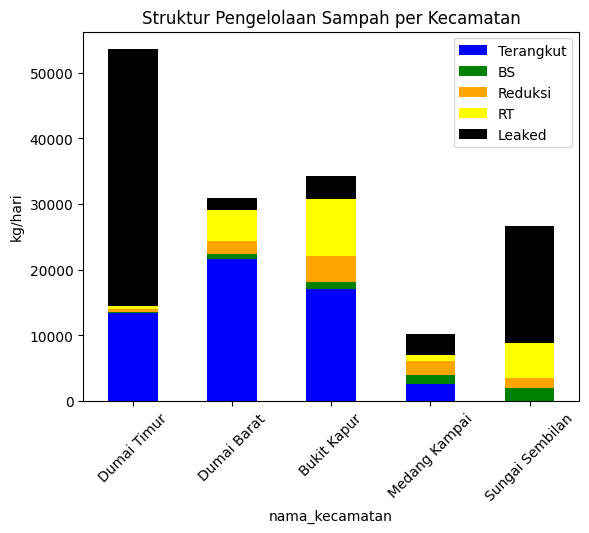

In [108]:
# pembuatan diagram batang struktur pengelolaan sampah per kecamatan
# ========================================================================

df_plot = df.set_index("nama_kecamatan")[["Terangkut","BS","Reduksi","RT","Leaked"]]
#CATATAN :
#   Terangkut = pelayanan armada pemkot
#   BS = Bank Sampah, TPST, TPS3R
#   RT = pengurangan sampah di RT (asumsi)
#   Reduksi = Lapak, Kawasan dll
#   Liar = TPS Liar, sampah menumpuk tanpa izin (bisa difoto)
#   Hidden = neraca massa sampah BALANCE

df_plot.plot(kind="bar", stacked=True,
             color={"Terangkut":"blue",
             "BS":"green",
             "Reduksi":"orange",
             "RT":"yellow",
             "Leaked":"black"})
plt.title("Struktur Pengelolaan Sampah per Kecamatan")
plt.ylabel("kg/hari")
plt.xticks(rotation=45)

plt.show()

In [109]:
# Hitung Index Pengurangan

df["Index_Pengurangan"] = (
    (df["Reduksi"] + df["Terolah"]) / df["Timbulan"]
)

In [110]:
# Output Tabel Index Pengurangan

print(df[["nama_kecamatan","Index_Pengurangan"]])

    nama_kecamatan  Index_Pengurangan
0      Dumai Timur           0.021194
1      Dumai Barat           0.238882
2      Bukit Kapur           0.395773
3    Medang Kampai           0.444828
4  Sungai Sembilan           0.331579


# 📊 WLSRI (Waste Local Service Resilience Index)

## 1. Definisi

**WLSRI (Waste Local Service Resilience Index)** adalah indeks komposit yang digunakan untuk menilai tingkat **kemandirian dan ketahanan sistem pengelolaan sampah** di suatu wilayah (misalnya kecamatan).

Indeks ini menggambarkan kemampuan wilayah dalam:

* menangani sampah yang dihasilkan,
* mengurangi ketergantungan pada sistem eksternal,
* meminimalkan kebocoran sampah ke lingkungan.

---

## 2. Komponen Penyusun

WLSRI disusun dari 4 komponen utama:

### 1. SPI (Service Performance Index)

Menggambarkan tingkat pelayanan pengangkutan sampah.

[
SPI = {Terangkut} / {Timbulan}
]

---

### 2. Reduksi Ratio

Menggambarkan kemampuan pengurangan sampah dari sumber (misalnya bank sampah, komposting).

[
Reduksi Ratio = {Reduksi} / {Timbulan}
]

---

### 3. Terolah Ratio

Menggambarkan kemampuan pengolahan sampah di dalam sistem.

[
Terolah Ratio = {Terolah} / {Timbulan}
]

---

### 4. Leakage Index

Menggambarkan tingkat kebocoran sampah ke lingkungan.

[
Leakage Index = {un-Manage} / {Timbulan}
]

dimana:
[
un-Manage = Liar + Hidden
]

---

## 3. Rumus WLSRI

[
WLSRI = (0.4 * SPI) + (0.2 * Reduksi Ratio) + (0.2 * Terolah Ratio) - (0.2 * Leakage Index)
]

---

## 4. Interpretasi Nilai

| Nilai WLSRI | Interpretasi                       |
| ----------- | ---------------------------------- |
| > 0.70      | Sistem sangat mandiri dan efektif  |
| 0.50 – 0.70 | Sistem cukup baik                  |
| 0.30 – 0.50 | Sistem sedang, perlu intervensi    |
| < 0.30      | Sistem lemah, prioritas penanganan |

---

## 5. Makna Analitis

WLSRI memberikan gambaran keseimbangan antara:

✔ **Kinerja pelayanan (SPI)**
✔ **Upaya pengurangan (Reduksi)**
✔ **Kapasitas pengolahan (Terolah)**
❌ **Kebocoran sistem (Leakage)**

Sehingga indeks ini dapat digunakan untuk:

* menentukan prioritas intervensi kebijakan,
* membandingkan kinerja antar kecamatan,
* mengidentifikasi titik lemah sistem pengelolaan sampah.

---

## 6. Catatan Penting

* Bobot (0.4, 0.2, 0.2, 0.2) dapat disesuaikan dengan kebijakan daerah.
* WLSRI bersifat **komparatif**, sehingga lebih kuat digunakan untuk perbandingan antar wilayah.
* Akurasi indeks sangat bergantung pada kualitas data timbulan dan pengelolaan.

---


In [111]:
# Hitung WLSRI

df["SPI"] = df["Terangkut"] / df["Timbulan"]
df["Reduksi_Ratio"] = df["Reduksi"] / df["Timbulan"]
df["Terolah_Ratio"] = df["Terolah"] / df["Timbulan"]
df["Leakage_Index"] = df["persen_kebocoran"] / 100

df["WLSRI"] = (
    0.5 * df["SPI"] +
    0.25 * df["Reduksi_Ratio"] +
    0.15 * df["Terolah_Ratio"] -
    0.1 * df["Leakage_Index"]
)

In [112]:
# Klasifikasi WLSRI

def klasifikasi(x):
    if x < 0:
        return "KRISIS"
    elif x < 0.2:
        return "BURUK"
    elif x < 0.4:
        return "SEDANG"
    else:
        return "BAIK"

df["kategori_wlsri"] = df["WLSRI"].apply(klasifikasi)

In [113]:
# Tabel WLSRI

print(df[["nama_kecamatan","WLSRI","kategori_wlsri"]])

    nama_kecamatan     WLSRI kategori_wlsri
0      Dumai Timur  0.056231          BURUK
1      Dumai Barat  0.386185         SEDANG
2      Bukit Kapur  0.310605         SEDANG
3    Medang Kampai  0.180911          BURUK
4  Sungai Sembilan -0.011466         KRISIS


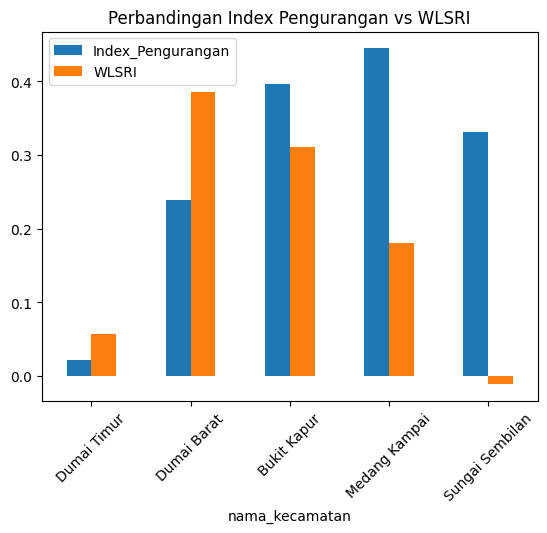

In [114]:
# Diagram Perbandingan Index_Pengurangan dan WLSRI

df_compare = df.set_index("nama_kecamatan")[["Index_Pengurangan","WLSRI"]]

df_compare.plot(kind="bar")
plt.title("Perbandingan Index Pengurangan vs WLSRI")
plt.xticks(rotation=45)
plt.show()

PEMETAAN WLSRI

In [115]:
# 1. Upload SHP    CATATAN : klo sdh upload bisa di frezze dg "#" saja

# from google.colab import files
# files.upload()

In [116]:
# 2. Cek penamaan file peta

print(gdf.columns)

Index(['nama_kecamatan', 'kode_kecam', 'luas_wilay', 'geometry', 'No',
       'Penduduk', 'Rasio', 'Timbulan', '% pelayanan', 'Terangkut', 'BS',
       '%RT', 'RT', 'Terolah', 'Reduksi', 'Liar', 'Hidden', 'Leaked',
       '%Leaked', 'persen_kebocoran', 'Index_Pengurangan', 'SPI',
       'Reduksi_Ratio', 'Terolah_Ratio', 'Leakage_Index', 'WLSRI',
       'kategori_wlsri'],
      dtype='object')


In [117]:
gdf = gpd.read_file("kecamatan_dumai.shp")

gdf = gdf.rename(columns={"nama_kecam":"nama_kecamatan"})

In [118]:
# inti analisis

gdf["nama_kecamatan"] = gdf["nama_kecamatan"].str.lower().str.strip()
df["nama_kecamatan"] = df["nama_kecamatan"].str.lower().str.strip()

#  3. MERGE

gdf = gdf.merge(df, on="nama_kecamatan")

In [119]:
def warna(x):
    if x < 0:
        return "red"
    elif x < 0.2:
        return "orange"
    elif x < 0.4:
        return "yellow"
    else:
        return "green"

In [120]:
center = gdf.geometry.unary_union.centroid

m = folium.Map(location=[center.y, center.x], zoom_start=11)

folium.GeoJson(
    gdf,
    style_function=lambda x: {
        'fillColor': warna(x['properties']['WLSRI']),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["nama_kecamatan","WLSRI","kategori_wlsri"],
        aliases=["nama_kecamatan","WLSRI","Status"]
    )
).add_to(m)

m

/tmp/ipykernel_7388/1260620615.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf.geometry.unary_union.centroid


HASIL OUTPUT SESUAI PERMINTAAN

✔ Tabel data + kebocoran
✔ Diagram struktur
✔ Tabel index pengurangan
✔ Diagram komponen
✔ Tabel WLSRI
✔ Diagram perbandingan
✔ Peta WLSRI

ANTI ERROR CHECKLIST (PENTING BANGET)

Kalau error, cek ini:

Nama kolom sama persis
Data numeric (bukan teks)
Nama kecamatan sama
File shp sesuai kota